## 1) 결정 트리(Decision Tree)
* 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리 기반의 분류 규칙을 만드는 것
* 데이터의 어떤 기준을 바탕으로 규칙을 만들어야 가장 효율적 분류인지가 알고리즘의 성능 좌우
* 결정 트리의 규칙 노드, 분할
  * 데이터셋에 피처가 있고 이런 피처가 결합해 규칙 조건을 만들 때마다 규칙 노드가 만들어짐
  * 많은 규칙이 있음 -> 분류 결정 방식이 복잡해짐 -> 과적합이 되기 쉬움 ==> 트리 깊이가 깊어질수록 결정트리 예측 성능 저하 가능성 있음
  * 가능한한 적은 결정 노드로 높은 예측 정확도 가지려면? 데이터 분류 시 최대한 많은 데이터셋이 해당 분류에 속하도록 결정 노드의 규칙 정해져야 함
  * 어떻게 트리를 분할할 것인가가 중요. 최대한 균일한 데이터 세트를 구성하도록 분할해야 함
* 균일도
  * 데이터셋의 균일도는 데이터 구분 시 필요한 정보양에 영향을 미침
  * 결정 노드는 정보 균일도가 높은 데이터셋을 먼저 선택하도록 규칙 조건 만듦
* 정보 균일도 측정 방법
  * 정보 이득(information gain)
    * 엔트로피(주어진 데이터 집합의 혼잡도) 기반
    * 서로 다른 값이 섞이면 엔트로피가 높음
    * (정보이득지수) = 1 - (엔트로피 지수)
    * 정보 이득이 높은 속성을 기준으로 분할함
  * 지니 계수
    * 0이 가장 평등하고 1이 가장 불평등
    * 지니계수가 낮을수록 데이터 균일도가 높음 -> 낮은 속성을 기준으로 분할
* 사이킷런 결정 트리 알고리즘 : DecisionTreeClassifier
  * 지니 계수를 이용해 데이터셋 분할
  * 정보 이등 높거나 지니 계수 낮은 조건 찾음 -> 자식 트리 노드 걸쳐 반복적 분할 -> 데이터가 모두 특정 분류 속하면 분할 멈춤 -> 분류 결정

## 2) 결정 트리 모델의 특징
* 정보의 균일도라는 룰을 기반으로 함 -> 알고리즘 쉽고 직관적
* 룰이 매우 명확 & 이를 기반으로 규칙 노드와 리프 노드 만들어지는지 알 수 있음
* 시각화로 표현 가능
* 각 피처의 스케일링과 정규화 등 전처리 작업 필요 없음. 사전 가공 영향도 크지 않음
* 과적합으로 정확도가 떨어짐
* 서브트리 계속 만들다보면 깊이 깊어지고 복잡해짐
* 트리 크기를 사전에 제한하는 것이 성능 튜닝에 더 도움이 됨

## 3) 결정 트리 파라미터
* DecisionTreeClassifier(분류를 위한 클래스) / DecisionTreeRegressor(회귀를 위한 클래스)
* 사이킷런의 결정 트리 구현은 CART(Classification And Regression Trees) 알고리즘 기반
* 파라미터
  * min_sample_split : 노드 분할하는 최소한의 샘플 데이터 수. 과적합 제어에 사용. 작게 설정할수록 분할되는 노드 많아져 과적합 증가. 디폴트=2
  * min_smaples_leaf : 말단 노드(leaf)가 되기 위한 최소한의 샘플 데이터 수. 과적합 제어용. 비대칭적 데이터의 경우 특정 ㅡㄹ래스 데이터 매우 작을 수 있으므로 작게 설정해야 함
  * max_features : 최적의 분할 위해 고려할 최대 피처 개수. 디폴트는 None(데이터셋의 모드 피처 대상 분할 수행). inf, float, log 등 옵션 있음
  * max_depth : 트리 최대 깊이. 디폴트는 None(완벽하게 클래스 결정값이 될때까지 깊이를 계속 키우며 분할/min_samples_split 보다 작아질 떄까지 깊이 증가시킴). 깊이 깊어지면 과적합 가능
  * max_leaf_nodes : 말단 노드의 최대 개수

## 4) 결정 트리 모델의 시각화
* Graphviz 패키지 사용
* export_graphviz() API 제공 : 함수 인자로 학습이 완료된 estimator, 피처 이름 리스트, 레이블 이름 리스트 입력
* C/C++ 운영체제 포팅된 패키지 -> 파이썬과 인터페이스할 수 있는 Wrapper 모듈을 별도 설치 해야함


In [6]:
### 모듈 임포트

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
from sklearn.datasets import make_classification

import graphviz
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings('ignore')

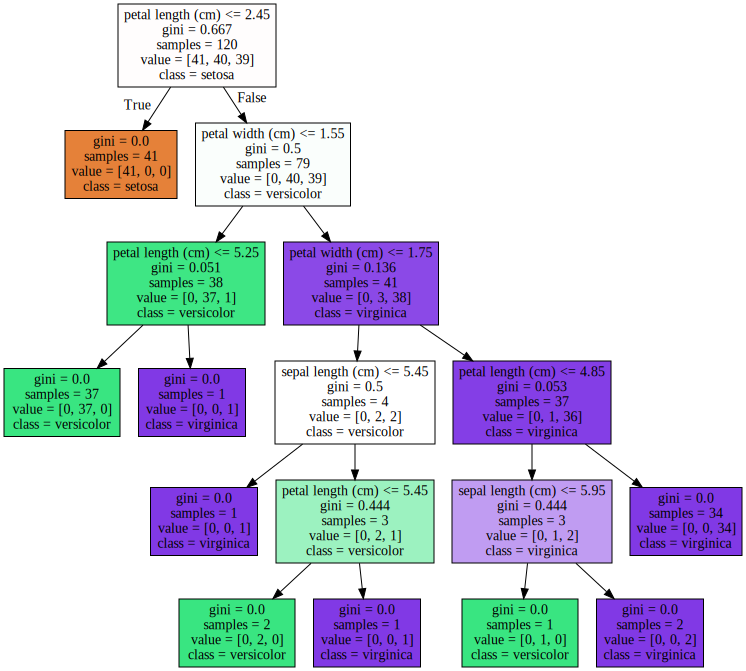

In [3]:
dt_clf = DecisionTreeClassifier(random_state=156)
iris_data = load_iris()
x_train, x_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=11)
dt_clf.fit(x_train, y_train)

export_graphviz(dt_clf, out_file="tree.dot", class_names =iris_data.target_names, \
               feature_names=iris_data.feature_names, impurity=True, filled=True)
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

* 리프 노드
  * 더 이상 자식 노드가 없는 노드
  * 최종 클래스(레이블)값이 결정됨
  * 오직 하나의 클래스값으로 최종 데이터 구성되거나 / 리프 노드가 될 수 있는 하이퍼 파라미터 조건을 충족해야 함
* 브랜치 노드
  * 자식이 있는 노드
  * 자식 노드를 만들기 위한 분할 규칙 조건을 가지고 있음
* 위 그림에 표시된 지표의 의미
  * petal length(cm) < 3.45 등의 피처 조건 -> 자식 노드 만들기 위한 규칙 조건. 이 조건이 없으면 리프 노드임
  * gini : 다음으니 value=[]로 주어진 데이터 분포 내에서의 지니 계수
  * samples : 현 규칙에 해당하는 데이터 건수
  * value=[] : 클래스 값 기반의 데이터 건수. 붓꽃 데이터 레이블은 3개로 value=[1, 2, 3]이라면 각각 0레이블이 1건, 1레이블이 2건, 2레이블이 3건이란 의미
  * 색이 짙어질 수록 지니 계수가 낮고 해당 레이블에 속하는 샘플 데이터가 많다는 의미임

# 결정트리 알고리즘을 제어하는 하이퍼 파라미터
* 복잡한 트리가 생성되는 것을 방지
* max_depth : 결정 트리의 최대 깊이 제어
* min_samples_splits : 자식 규칙 노드를 분할해 만들기 위한 최소한의 샘플 데이터 개수
* min_damples_leaf : 리프 노드가 될 수 있는 샘플 데이터 건수의 최솟값
  * 디폴트=1 -> 다른 클래스 값이 하나도 없이 단독 클래스로만 되어 있거나 / 단 한 개의 데이터로 되어있을 때는 리프 노드가 될 수 있다
  * 'min_samples_leaf <= (지정값)' 기준을 만족해야 리프 노드가 될 수 있음

# feature_importances 속성
* 결정 트리는 균일도에 기반해 어떤 속성을 규칙 조건으로 선택하는가가 중요함
  * 중요 몇 개 피처가 명확한 규칙 트리 만드는 데 기여 -> 모델을 간결하고 이상치(outlier)에 강한 모델 만들 수 있음
* 사이킷런에서는 규칙 정할 때 피처의 중요한 역할 지표를 DecisionTreeClassifier.feature_importances_속성으로 제공
  * 넘파이 배열 형태로 값 반환 & 피처 순서대로 값 할당됨
  * 값이 높을수록 해당 피처의 중요도가 높다는 의미임

Feature importances

sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


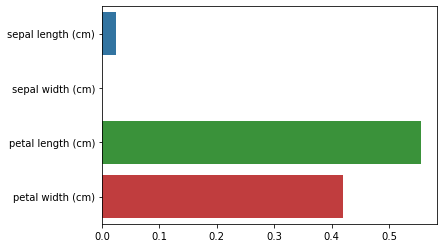

In [5]:
print('Feature importances\n')
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print('{0} : {1:.3f}'.format(name, value))
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

# 트리 과적합
* 사이킷런은 분류 위한 테스트용 데이터 쉽게 만드는 make_classification() 함수 제공

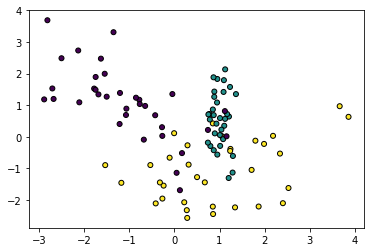

In [7]:
#2개의 피처가 3가지 유형의 클래스 값을 가지는 데이터셋을 만들고, 이를 시각화해보자

x_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2, n_classes=3, n_clusters_per_class=1, random_state=0)
plt.scatter(x_features[:, 0], x_features[:, 1], marker='o', c=y_labels, s=25, edgecolor='k')

In [8]:
#결정 트리 생성시 어떤 결정 기준 가지고 분할하며 데이터 분류하는지 확인하자
# 머신러닝 모델이 클래스 값을 예측하는 결정 기준을 색상&경계로 나타내는 함수
def visualize_boundary(model, X, y):
    fig,ax = plt.subplots()
    
    # 학습 데이타 scatter plot으로 나타내기
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start , xlim_end = ax.get_xlim()
    ylim_start , ylim_end = ax.get_ylim()
    
    # 호출 파라미터로 들어온 training 데이타로 model 학습 . 
    model.fit(X, y)
    # meshgrid 형태인 모든 좌표값으로 예측 수행. 
    xx, yy = np.meshgrid(np.linspace(xlim_start,xlim_end, num=200),np.linspace(ylim_start,ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # contourf() 를 이용하여 class boundary 를 visualization 수행. 
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)

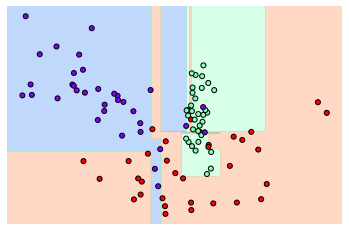

In [11]:
dt_clf = DecisionTreeClassifier().fit(x_features, y_labels)
visualize_boundary(dt_clf, x_features, y_labels)

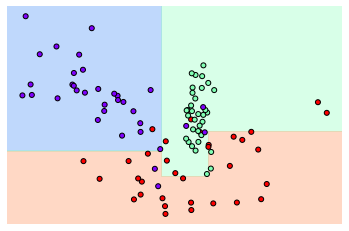

In [12]:
# min_samples_leaf를 변경해 다시 살펴보기

dt_clf = DecisionTreeClassifier(min_samples_leaf=6).fit(x_features, y_labels)
visualize_boundary(dt_clf, x_features, y_labels)